In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from google.colab import drive
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_path = "/content/drive/MyDrive/Colab Notebooks/dataset/train"
test_path = "/content/drive/MyDrive/Colab Notebooks/dataset/test"

In [5]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
          rotation_range=20,
              zoom_range=0.2,
                  horizontal_flip=True,
                      validation_split=0.2
                      )


In [6]:
test_datagen = ImageDataGenerator(
      rescale=1./255
      )


In [7]:
import os
print(os.listdir(train_path))
print(os.listdir(test_path))

['healthy', 'down_syndrome']
['down_syndrome', 'healthy']


In [8]:
import os
import shutil
import random

# Original dataset path
source_path = "/content/drive/MyDrive/Colab Notebooks/dataset/train"

# New test path
test_path = "/content/drive/MyDrive/Colab Notebooks/dataset/test"

classes = ["down_syndrome", "healthy"]

for cls in classes:
    source_folder = os.path.join(source_path, cls)
    test_folder = os.path.join(test_path, cls)

    os.makedirs(test_folder, exist_ok=True)

    images = os.listdir(source_folder)
    random.shuffle(images)

    split_size = int(0.2 * len(images))  # 20% for testing
    test_images = images[:split_size]

    for img in test_images:
        src = os.path.join(source_folder, img)
        dst = os.path.join(test_folder, img)
        shutil.move(src, dst)

print("Train-Test Split Completed")


Train-Test Split Completed


In [9]:
train_generator = train_datagen.flow_from_directory(
      train_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      subset='training'
                      )


Found 788 images belonging to 2 classes.


In [10]:
val_generator = train_datagen.flow_from_directory(
      train_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      subset='validation'
                      )


Found 196 images belonging to 2 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
      test_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      shuffle=False
                      )


Found 2015 images belonging to 2 classes.


In [12]:
model = Sequential([

      Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
          MaxPooling2D(2,2),

              Conv2D(64, (3,3), activation='relu'),
                  MaxPooling2D(2,2),

                      Conv2D(128, (3,3), activation='relu'),
                          MaxPooling2D(2,2),

                              Flatten(),

                                  Dense(128, activation='relu'),
                                      Dropout(0.5),

                                          Dense(1, activation='sigmoid')
                                          ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
      optimizer='adam',
          loss='binary_crossentropy',
              metrics=['accuracy']
              )


In [14]:
early_stop = EarlyStopping(
      monitor='val_loss',
          patience=5,
              restore_best_weights=True
              )


In [15]:
history = model.fit(
      train_generator,
          validation_data=val_generator,
              epochs=15,
                  callbacks=[early_stop]
                  )


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 276s 11s/step - accuracy: 0.5787 - loss: 0.7682 - val_accuracy: 0.5663 - val_loss: 0.6807
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 640ms/step - accuracy: 0.6434 - loss: 0.6396 - val_accuracy: 0.6020 - val_loss: 0.6581
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step - accuracy: 0.6751 - loss: 0.6084 - val_accuracy: 0.5918 - val_loss: 0.6574
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.7069 - loss: 0.5700 - val_accuracy: 0.6684 - val_loss: 0.6313
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 635ms/step - accuracy: 0.7069 - loss: 0.5761 - val_accuracy: 0.6276 - val_loss: 0.6487
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 630ms/step - accuracy: 0.7132 - loss: 0.5597 - val_accuracy: 0.6531 - val_loss: 0.6217
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.7360 - loss: 0.5281 - val_accuracy: 0.6429 - val_loss: 0.6274
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.7563 - loss: 0.5026 - val_accur

In [16]:
test_loss, test_acc = model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc * 100, "%")

20/63 ━━━━━━━━━━━━━━━━━━━━ 11:58 17s/step - accuracy: 0.6137 - loss: 0.6823

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 1078s 17s/step - accuracy: 0.7479 - loss: 0.5095
CNN Test Accuracy: 74.7890830039978 %


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

# True labels
y_true = test_generator.classes

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.68      0.73      1008
           1       0.72      0.81      0.76      1007

    accuracy                           0.75      2015
   macro avg       0.75      0.75      0.75      2015
weighted avg       0.75      0.75      0.75      2015

Confusion Matrix:

[[688 320]
 [188 819]]


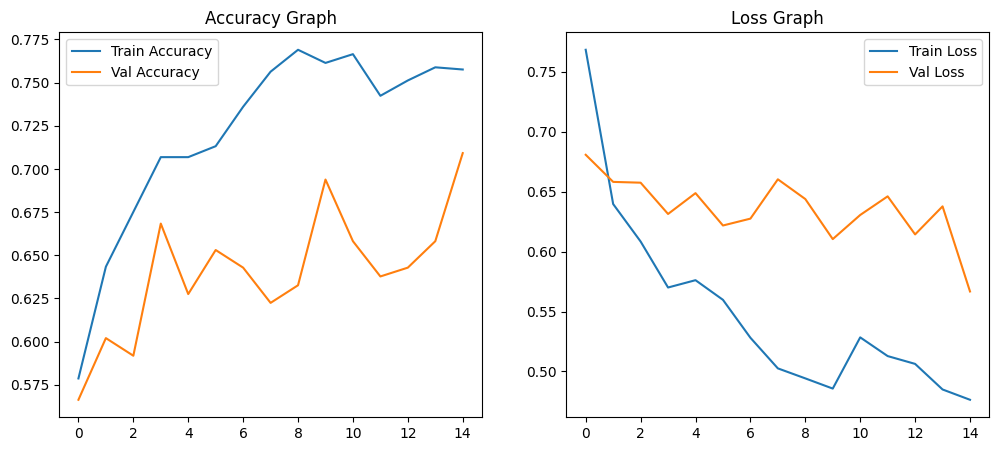

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")

plt.show()

Text(45.722222222222214, 0.5, 'Actual')

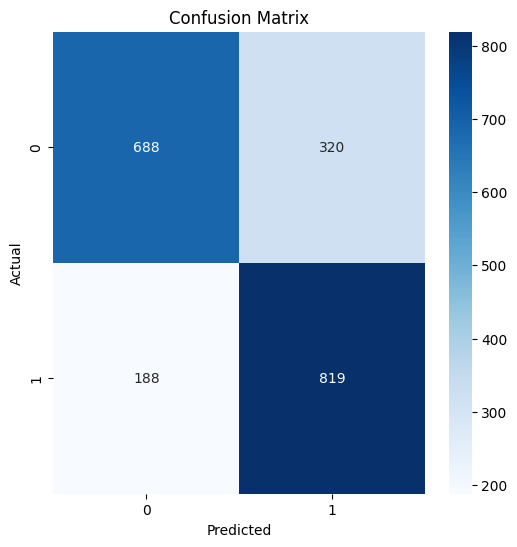

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")